In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import sklearn.model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5')

In [3]:
howmany=int(1e5)

In [44]:
X=[]
for l in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']:
    X.append(f[l][:howmany])
X = np.array(X).T
y = np.array(f['det'][:howmany])

In [45]:
np.sum(y)/len(y) #cuantos son en realidad ondas gravitacionales de todo lo que se detecto??

np.float64(0.14382)

In [46]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.30, random_state=67)

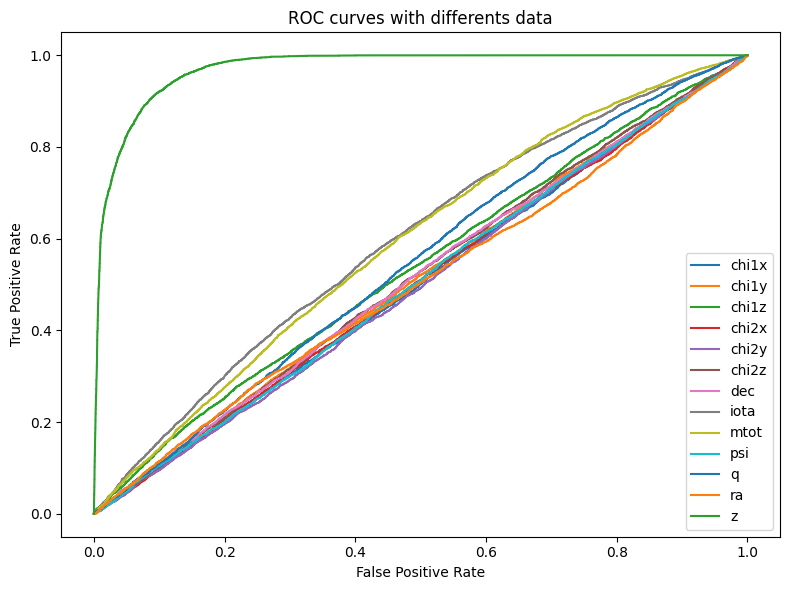

In [8]:
#Lets do something like simple in order to know which one is the best dimention?
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.30, random_state=67)

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_curve

clf = QuadraticDiscriminantAnalysis()

names = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']

plt.figure(figsize=(8,6))

for i in range(len(names)):
    clf.fit(X_train[:,i:i+1], y_train)
    y_prob = clf.predict_proba(X_test[:,i:i+1])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    label_text = f"{names[i]}"
    plt.plot(fpr, tpr, label=label_text)

plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves with differents data")
#plt.xlim(0, 0.1)
#plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

In [29]:
#lets wok with with a combination of z, mtot, iota lets see

X_sub=[]
for l in ['iota', 'mtot','z']:
    X_sub.append(f[l][:howmany])
X_sub = np.array(X_sub).T

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X_sub, y, test_size=0.3, random_state=42)

In [30]:
clf = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
C #wao i improve in one direction

array([[25062,   616],
       [  818,  3504]])

In [31]:
print(np.sum(C.diagonal())/len(y_test))
y_prob = clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_prob)

0.9522


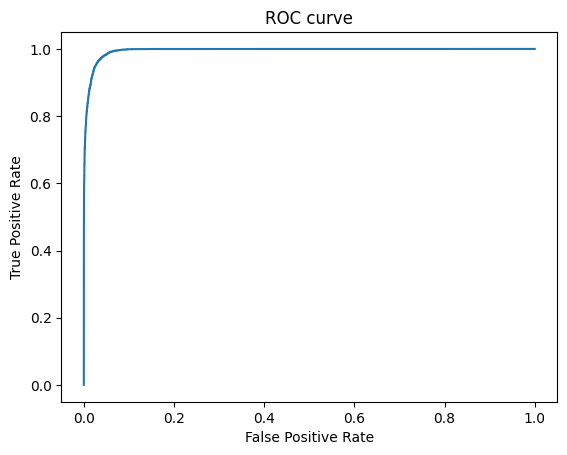

In [57]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve");
# you can epxlore more on this ok.

In [49]:
#here lets stat to learn about GW using 

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

#elijo con cross validatio el mejor

sc = StandardScaler() 
Xs = sc.fit_transform(X) #solo se normaliza ka wa con el media 0 y varianza 1 recuerda

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(Xs, y, test_size=0.33, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(5,), (5,5), (10,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}

mlp = MLPClassifier(alpha=0, learning_rate_init=0.001)

gscv = GridSearchCV(mlp, param_grid, cv=5)
gscv.fit(X_train[:50000], y_train[:50000])  # Solo para que se entrene rápido

gscv.best_params_

C:\Users\kevin\anaconda3\envs\tfenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\anaconda3\envs\tfenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\kevin\anaconda3\envs\tfenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\kevin\anaconda3\envs\tfenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\kevin\anaconda3\envs\tfenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warn

{'activation': 'tanh',
 'hidden_layer_sizes': (10,),
 'max_iter': 200,
 'solver': 'adam'}

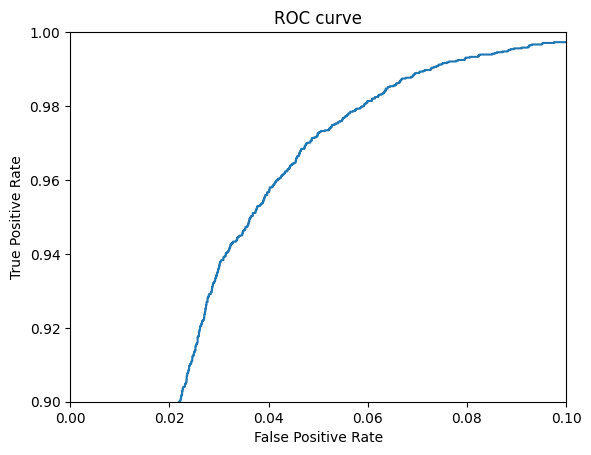

In [59]:
#plot the best
bestclf = gscv.best_estimator_

bestclf.fit(X_train, y_train)
y_prob=bestclf.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.xlim(0,0.1)
plt.ylim(0.9,1);

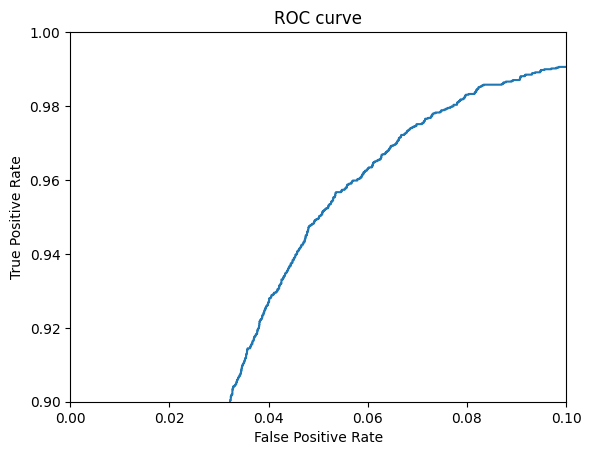

In [62]:
#aqui solo para que veas que pasa si no eliges el mejor)

clf = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(5), 
    activation='relu',
    solver='adam',
    alpha=0,
    learning_rate_init=0.001,
    max_iter=200)

clf.fit(X_train[:10000], y_train[:10000]) #learn how to clisify

y_prob2=clf.predict_proba(X_test)[:,1]

fpr, tpr, thresh = roc_curve(y_test, y_prob2) #compared the data test and what you learn
plt.plot(fpr, tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve");

In [61]:
#matrices de confusino para por curiosidad
y_predict2=clf.predict(X_test)
y_predict=bestclf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_predict)
C2 = sklearn.metrics.confusion_matrix(y_test, y_predict2)
print("For a random hyperparamter you get " + str(np.sum(C2.diagonal())/len(y_test)))
print("For the best hyperparameters you get " + str(np.sum(C.diagonal())/len(y_test)))
#aqui se ve que el mejor seria C que entrenamos con CV

For a random hyperparamter you get 0.9599090909090909
For the best hyperparameters you get 0.9668484848484848


In [63]:
#the effeiency es lo mismo que tp + tn sobre total, solo para comprobar 
tn, fp, fn, tp = C.ravel()
print((tp+tn)/len(y_test))

0.9668484848484848


In [64]:
gscv.best_score_ #how many they identify , is this the completeness?

np.float64(0.96922)

In [65]:
#le hacemos un poco de tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Modelo simple en Keras
def build_model(hidden_layers=(5,), activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(keras.Input(shape=(Xs.shape[1],)))

    for h in hidden_layers:
        model.add(layers.Dense(h, activation=activation))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Construcción y entrenamiento del modelo
model = build_model(hidden_layers=(10, 10), activation='tanh', learning_rate=0.001)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)

# Evaluación y curva ROC
y_prob = model.predict(X_test).ravel()
fpr, tpr, thresh = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlim(0, 0.1)
plt.ylim(0.9, 1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Keras)")
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [67]:
#desition tree, this is actually the lesson #20 still
clf = DecisionTreeClassifier()
drange = np.arange(1,21)  #Complete

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5) #Complete
grid.fit(X_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)



best parameter choice: 8


In [68]:
clf = DecisionTreeClassifier(random_state=0, max_depth=best,criterion='entropy')
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(8),
                       random_state=0)

In [69]:
y_pred = clf.predict(X_test)

In [70]:
# Confusion matrix
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
C

array([[27562,   657],
       [  756,  4025]])

In [71]:
# Efficiency (i.e. number of things classified correctly)
np.sum(C.diagonal())/len(y_test)

np.float64(0.9571818181818181)

In [72]:
# These are the counts
tn, fp, fn, tp = C.ravel()
print(fn)
print(C.ravel())

756
[27562   657   756  4025]


In [73]:
y_prob = clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_prob)

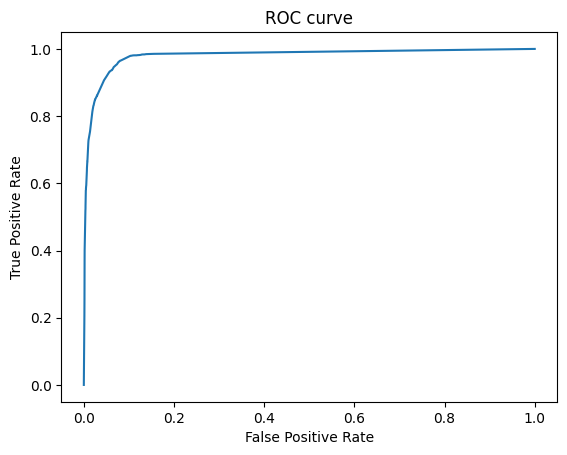

In [75]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve");

In [77]:
print("completeness test is " + str(tp/(tp+fn)))
print("contamination test is " + str(fp/(tp+fp)))

completeness test is 0.8418740849194729
contamination test is 0.14032464758650148


In [21]:
# Let's see if I can improve things with a random forest

In [78]:
clf = RandomForestClassifier(n_estimators=200, max_depth=8, criterion='entropy',n_jobs=-1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = C.ravel()
print("completeness test", tp/(tp+fn))
print("contamination test", fp/(tp+fp))

y_pred = clf.predict(X_train)
C = sklearn.metrics.confusion_matrix(y_train, y_pred)
tn, fp, fn, tp = C.ravel()
print("completeness train", tp/(tp+fn))
print("contamination train", fp/(tp+fp))

completeness test 0.8130098305793767
contamination test 0.1066421512296024
completeness train 0.8251223830850953
contamination train 0.09182620658030494


In [79]:
y_pred = clf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
np.sum(C.diagonal())/len(y_test)

np.float64(0.9588484848484848)

In [25]:
#algo se mejoro pero no esta del todo clar, de todas formas esta pepa eh , acutallt improse 1% waooooo

In [5]:
# Last but not least, bueno primero hagamos todo el proceso de saber la data, y clasificarla con los colores nuevos y si pertenecen a una galaxia o no

data=np.genfromtxt('galaxyquasar.csv', delimiter=',',names=True,usecols=(0,1,2,3,4,6),dtype=float,comments='#') #reading the file

names = data.dtype.names

data=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=(0,1,2,3,4,6),dtype=float)

d = dict(zip(names, data.T))

lab=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=5,dtype=str)

for diff in ['ug', 'gr', 'ri', 'iz']:
    d[diff]=d[diff[0]]-d[diff[1]] 
d['lab']=lab


d.keys()

dict_keys(['u', 'g', 'r', 'i', 'z', 'z1', 'ug', 'gr', 'ri', 'iz', 'lab'])

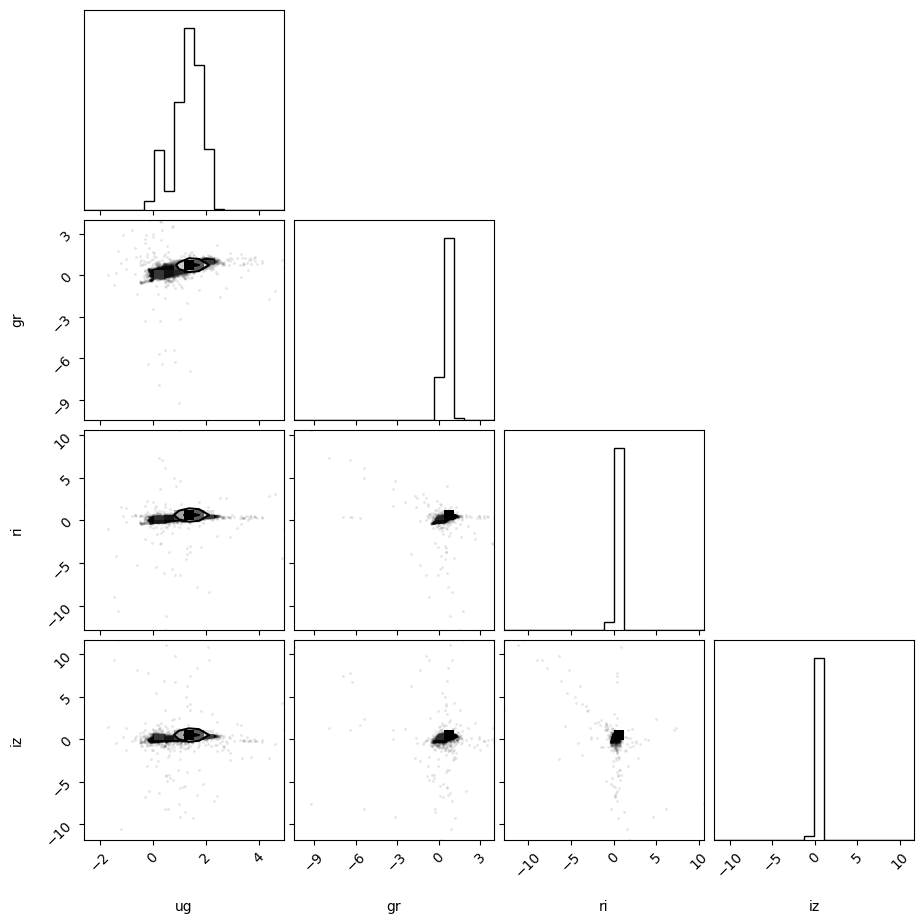

In [8]:
import corner
corner.corner(np.array([d['ug'],d['gr'],d['ri'],d['iz']]).T, labels=['ug', 'gr', 'ri', 'iz']);

(0.0, 3.0)

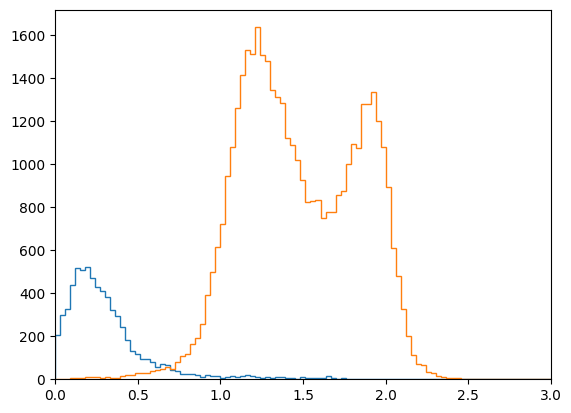

In [14]:
import matplotlib.pyplot as plt
plt.hist(d['ug'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100))
plt.hist(d['ug'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100))
plt.xlim(0,3)

(0.0, 3.0)

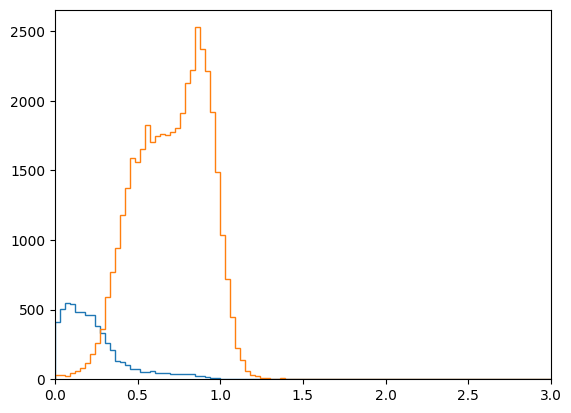

In [15]:
plt.hist(d['gr'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100))
plt.hist(d['gr'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100))
plt.xlim(0,3)

(0.0, 3.0)

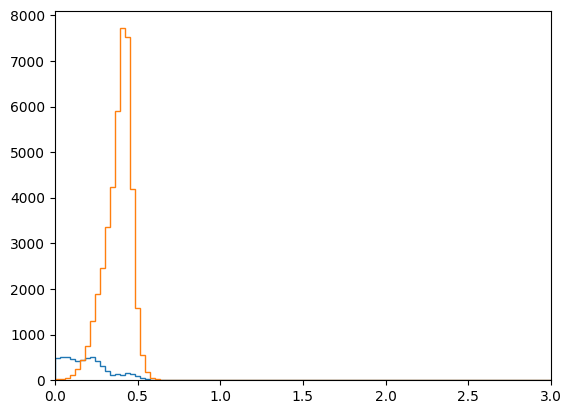

In [16]:
plt.hist(d['ri'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100))
plt.hist(d['ri'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100))
plt.xlim(0,3)

(0.0, 3.0)

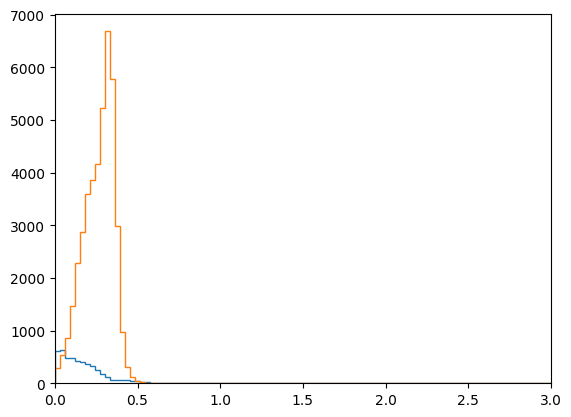

In [17]:
plt.hist(d['iz'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100))
plt.hist(d['iz'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100))
plt.xlim(0,3)

In [39]:
#bueno esto significa que debemos de clasificar viendo la ug??

import sklearn.model_selection
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [18]:
X=np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T
y = np.array(lab=='QSO',dtype=int)


sc = StandardScaler() 
Xs = sc.fit_transform(X) #solo se normaliza ka wa con el media 0 y varianza 1 recuerda

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(Xs, y, test_size=0.33, random_state=42)

In [44]:
clf = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(5), 
    activation='relu',
    solver='adam',
    alpha=0,
    learning_rate_init=0.001,
    max_iter=200)

In [45]:
clf.fit(X_train[:1000], y_train[:1000]) #learn how to clisify??

C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=0, hidden_layer_sizes=5)

In [46]:
y_prob=clf.predict_proba(X_test)[:,1] #apply what you learn to the test data

(0.9, 1.0)

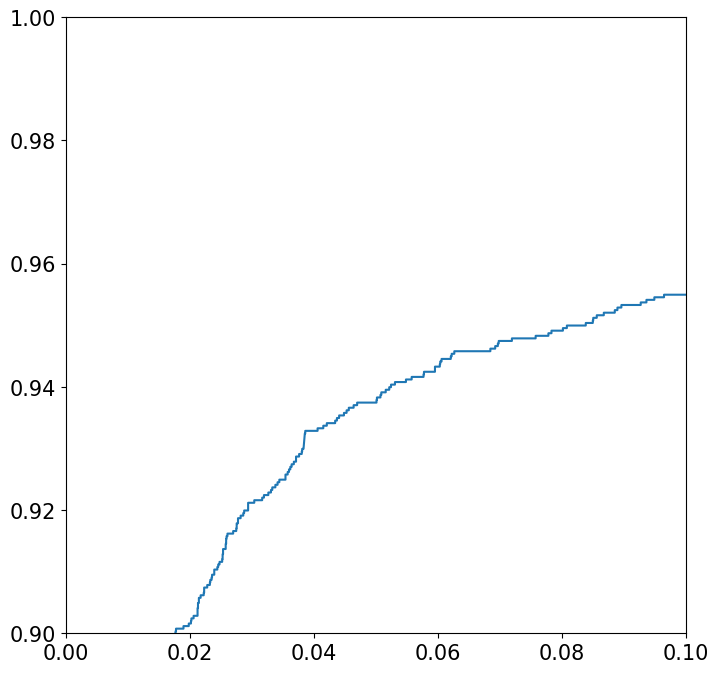

In [47]:
fpr, tpr, thresh = roc_curve(y_test, y_prob) #compared the data test and what you learn
plt.plot(fpr, tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)

In [50]:
param_grid = {
    'hidden_layer_sizes': [(5,), (5,5), (10,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}

mlp = MLPClassifier(alpha=0, learning_rate_init=0.001)

gscv = GridSearchCV(mlp, param_grid, cv=5)
gscv.fit(X_train[:1000], y_train[:1000])  # Solo para que se entrene rápido

gscv.best_params_

C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

{'activation': 'tanh',
 'hidden_layer_sizes': (10,),
 'max_iter': 200,
 'solver': 'adam'}

(0.9, 1.0)

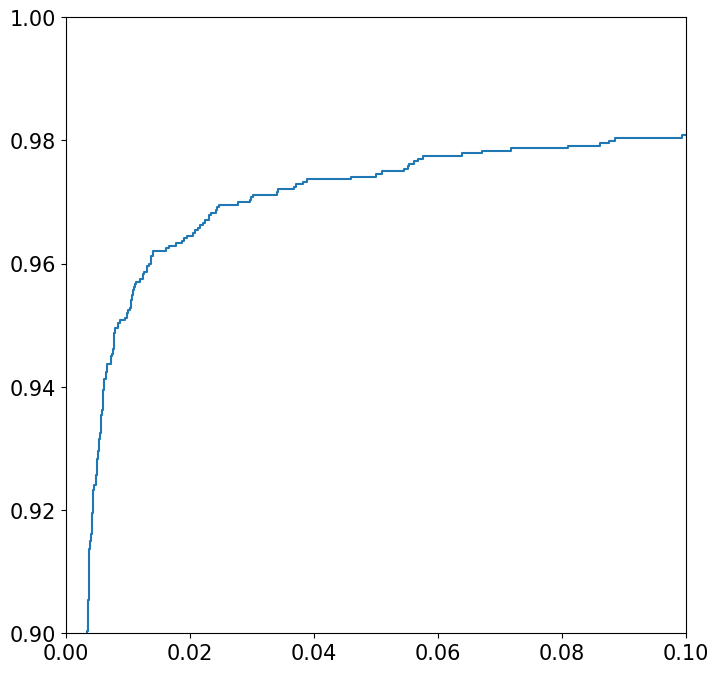

In [52]:
bestclf = gscv.best_estimator_

bestclf.fit(X_train, y_train)
y_prob=bestclf.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)

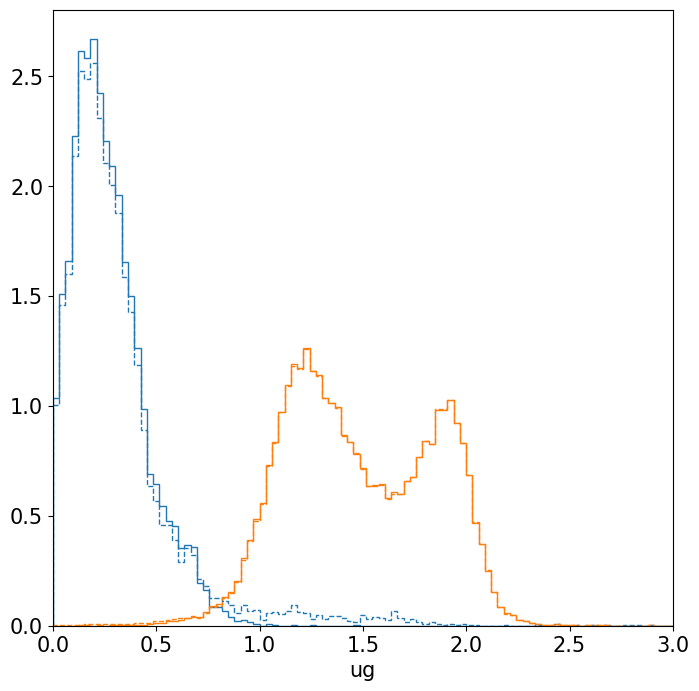

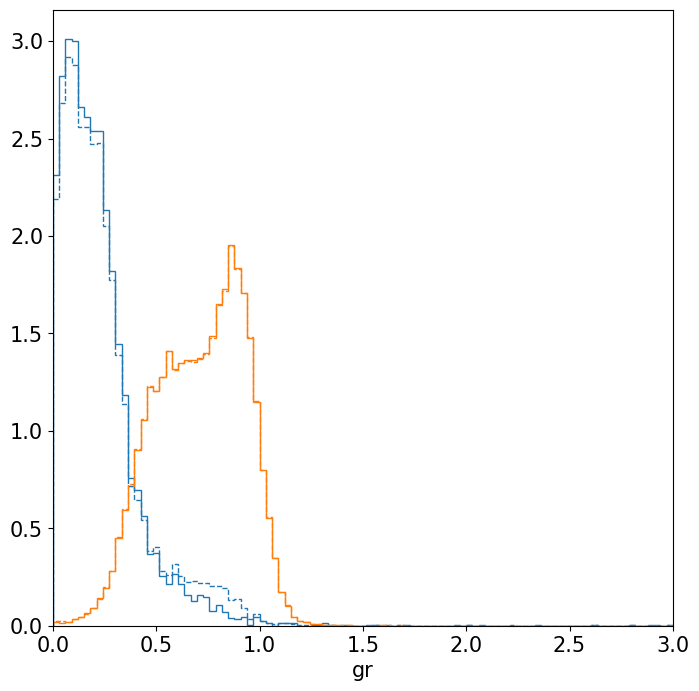

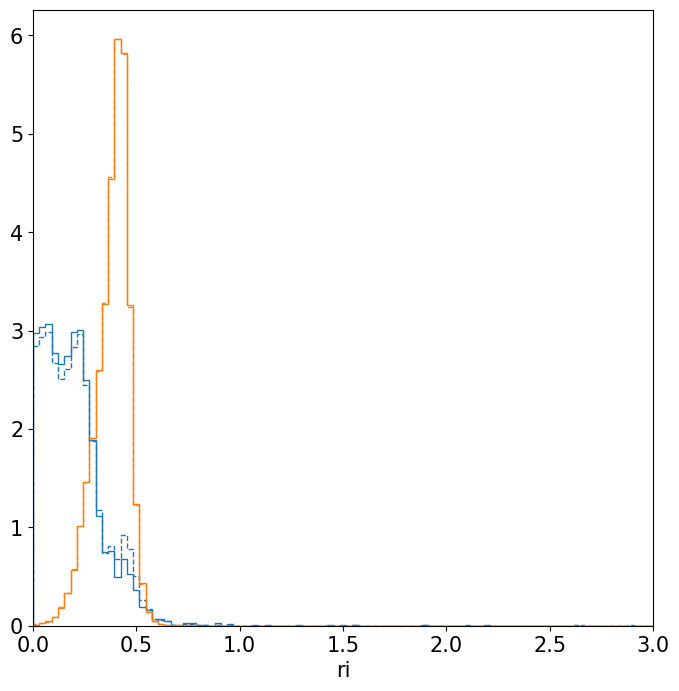

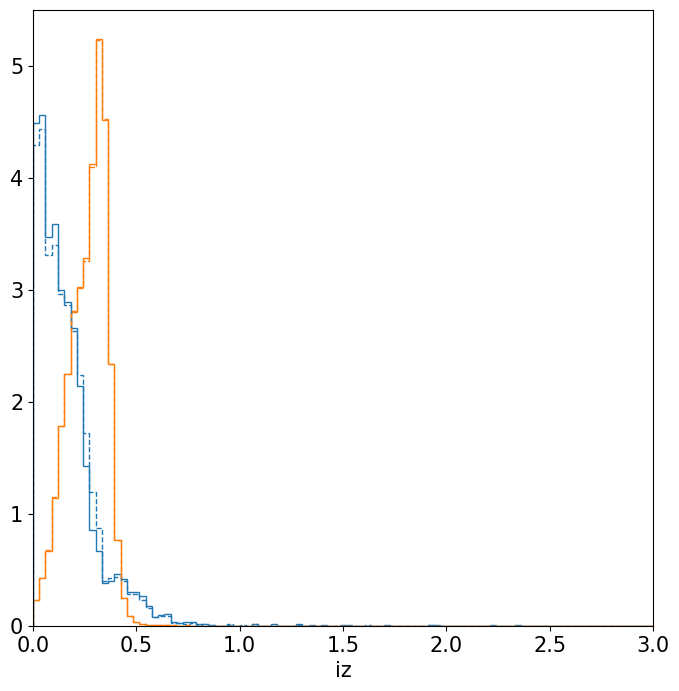

In [54]:
# lo mejoro?? si eveidentemente.

y_pred=bestclf.predict(Xs)

for col in ['ug', 'gr', 'ri', 'iz']:

    plt.hist(d[col][y_pred==1],histtype='step',bins=np.linspace(0,3,100),density=True,color='C0')
    plt.hist(d[col][y_pred==0],histtype='step',bins=np.linspace(0,3,100),density=True,color='C1')

    plt.hist(d[col][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100),density=True,color='C0',ls='dashed')
    plt.hist(d[col][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100),density=True,color='C1',ls='dashed')
    plt.xlim(0,3)
    plt.xlabel(col)
    plt.show()

#ok evidenemtnte es un buen clasificador xd 

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


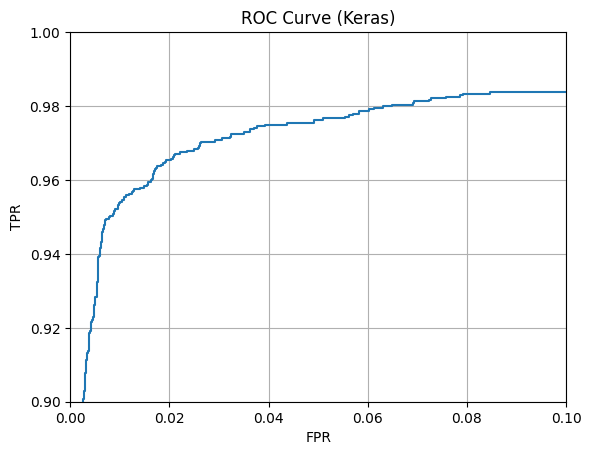

In [21]:
#alguna otra idea de como hacerlo?

#another proposta con 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve

# Modelo simple en Keras
def build_model(hidden_layers=(5,), activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(keras.Input(shape=(X.shape[1],)))

    for h in hidden_layers:
        model.add(layers.Dense(h, activation=activation))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Construcción y entrenamiento del modelo
model = build_model(hidden_layers=(10, 10), activation='tanh', learning_rate=0.001)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)

# Evaluación y curva ROC
y_prob = model.predict(X_test).ravel()
fpr, tpr, thresh = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlim(0, 0.1)
plt.ylim(0.9, 1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Keras)")
plt.grid(True)
plt.show()

In [20]:
for activation in ['relu', 'tanh']:
    for hl in [(5,), (5,5), (10,), (10,10)]:
        print(f'Testing: {activation}, {hl}')
        model = build_model(hidden_layers=hl, activation=activation)
        model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f'Test accuracy: {acc:.4f}')

Testing: relu, (5,)
Test accuracy: 0.9836
Testing: relu, (5, 5)
Test accuracy: 0.9841
Testing: relu, (10,)
Test accuracy: 0.9847
Testing: relu, (10, 10)
Test accuracy: 0.9863
Testing: tanh, (5,)
Test accuracy: 0.9840
Testing: tanh, (5, 5)
Test accuracy: 0.9853
Testing: tanh, (10,)
Test accuracy: 0.9848
Testing: tanh, (10, 10)
Test accuracy: 0.9867


In [22]:
# viste cual es el mejor y lo probaste, ahora veamos pues is va bien o no..